In [163]:
import pandas as pd
import numpy as np
import os

import nltk


In [164]:
# Chemin du dossier
DOSSIER = "data guerre au moyent orient/"  # Change si ton dossier s'appelle autrement

# Charger les 5 fichiers
df_conflict  = pd.read_csv(os.path.join(DOSSIER, "conflict_oil_events.csv"))
df_oil       = pd.read_csv(os.path.join(DOSSIER, "oil_jet_fuel_prices.csv"))
df_surcharge = pd.read_csv(os.path.join(DOSSIER, "fuel_surcharges.csv"))
df_airline   = pd.read_csv(os.path.join(DOSSIER, "airline_financial_impact.csv"))
df_route     = pd.read_csv(os.path.join(DOSSIER, "route_cost_impact.csv"))

## je commence par le df_conflict sur le prix du petrole brute

In [165]:
df_conflict.shape

(36, 14)

In [166]:
df_conflict.columns.tolist()

['event_date',
 'event_type',
 'event_description',
 'location',
 'severity',
 'brent_before_usd',
 'brent_after_usd',
 'oil_price_change_pct',
 'airfare_impact_pct',
 'days_since_prev_event',
 'conflict_phase',
 'flight_cancellations_est',
 'airspace_closures_countries',
 'data_source']

In [167]:
df_conflict.head()

,event_date,event_type,event_description,location,severity,brent_before_usd,brent_after_usd,oil_price_change_pct,airfare_impact_pct,days_since_prev_event,conflict_phase,flight_cancellations_est,airspace_closures_countries,data_source
0,2019-04-11,Political,Venezuela sanctions escalate; OPEC+ extends cuts,Global,Medium,67.5,72.3,7.1,2.5,NaN,Pre-Pandemic Baseline,1500,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
1,2019-06-13,Military,Tanker attacks in Gulf of Oman — Iran blamed,Strait of Hormuz,High,60.5,65.2,7.8,3.1,63.0,Pre-Pandemic Baseline,1671,2,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
2,2019-09-14,Military,Houthi drone strike hits Saudi Aramco faciliti...,"Abqaiq, Saudi Arabia",Very High,60.2,71.5,18.7,6.2,93.0,Pre-Pandemic Baseline,2737,3,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
3,2019-12-27,Political,US kills Iranian General Soleimani — tensions ...,"Baghdad, Iraq",Very High,66.0,70.7,7.1,3.4,104.0,Pre-Pandemic Baseline,1801,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
4,2020-01-08,Military,Iran fires missiles at US bases in Iraq,Iraq,Extreme,70.7,65.2,-7.7,4.8,12.0,Pre-Pandemic Baseline,2422,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...


In [168]:
df_conflict['severity'].value_counts()

severity
High         15
Extreme      10
Very High     7
Medium        4
Name: count, dtype: int64

In [169]:
df_conflict['conflict_phase'].value_counts()

conflict_phase
US-Iran War Conflict     9
Gaza-Israel Conflict     8
Pre-Pandemic Baseline    5
Pre-Iran Escalation      4
COVID-19 Collapse        3
Ukraine War Shock        3
Recovery & Surge         2
Stabilisation            2
Name: count, dtype: int64

In [170]:
df_conflict['oil_price_change_pct'].describe()

count    36.000000
mean      2.544444
std      13.520998
min     -39.000000
25%      -1.975000
50%       4.800000
75%       7.100000
max      31.300000
Name: oil_price_change_pct, dtype: float64

In [171]:
df_conflict['airfare_impact_pct'].describe()

count    36.000000
mean      5.575000
std       9.886827
min     -29.500000
25%       2.725000
50%       4.000000
75%       9.125000
max      25.000000
Name: airfare_impact_pct, dtype: float64

In [172]:
df_conflict['flight_cancellations_est'].describe()

count       36.00000
mean      4101.00000
std       3653.70493
min        548.00000
25%       1498.75000
50%       2331.50000
75%       5616.50000
max      15237.00000
Name: flight_cancellations_est, dtype: float64

In [173]:
df_conflict.isnull().sum()

event_date                     0
event_type                     0
event_description              0
location                       0
severity                       0
brent_before_usd               0
brent_after_usd                0
oil_price_change_pct           0
airfare_impact_pct             0
days_since_prev_event          1
conflict_phase                 0
flight_cancellations_est       0
airspace_closures_countries    0
data_source                    0
dtype: int64

In [174]:
df_oil.shape

(87, 12)

In [175]:
df_oil.columns.tolist()

['month',
 'conflict_phase',
 'brent_crude_usd_barrel',
 'jet_fuel_usd_barrel',
 'refinery_margin_usd',
 'jet_fuel_usd_per_gallon',
 'wti_crude_usd_barrel',
 'opec_production_mbd',
 'us_strategic_reserve_mbl',
 'strait_hormuz_disrupted',
 'yoy_brent_change_pct',
 'data_source']

In [176]:
df_oil.head(3)

,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,yoy_brent_change_pct,data_source
0,2019-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,NaN,EIA / Platts / IATA
1,2019-02,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,NaN,EIA / Platts / IATA
2,2019-03,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,NaN,EIA / Platts / IATA


In [177]:
df_oil['month'] = pd.to_datetime(df_oil['month'])

In [178]:
df_oil[['brent_crude_usd_barrel', 'jet_fuel_usd_barrel', 'refinery_margin_usd']].describe()

,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd
count,87.000000,87.000000,87.000000
mean,80.184368,93.624138,13.439770
std,24.499783,28.534755,4.620058
min,20.550000,23.690000,3.120000
25%,66.580000,76.920000,10.965000
50%,82.610000,94.920000,13.240000
75%,91.305000,109.105000,16.500000
max,169.080000,193.200000,26.660000


In [179]:
df_oil['yoy_brent_change_pct'].isnull().sum()

np.int64(12)

In [180]:
df_oil['yoy_brent_change_pct'].fillna(0, inplace=True)


C:\Users\JOHANN\AppData\Local\Temp\ipykernel_9340\1751282331.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_oil['yoy_brent_change_pct'].fillna(0, inplace=True)


In [181]:
df_oil['yoy_brent_change_pct'].isnull().sum()

np.int64(0)

In [182]:
df_oil.head()

,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,yoy_brent_change_pct,data_source
0,2019-01-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,0.0,EIA / Platts / IATA
1,2019-02-01,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,0.0,EIA / Platts / IATA
2,2019-03-01,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,0.0,EIA / Platts / IATA
3,2019-04-01,Pre-Pandemic Baseline,64.79,73.34,8.55,1.726,63.02,28.93,560.7,No,0.0,EIA / Platts / IATA
4,2019-05-01,Pre-Pandemic Baseline,61.25,72.97,11.72,1.813,59.07,28.13,392.0,No,0.0,EIA / Platts / IATA


## df_surcharge

In [183]:
df_surcharge.shape

(10092, 13)

In [184]:
df_surcharge.columns.tolist()

['month',
 'conflict_phase',
 'airline',
 'iata_code',
 'country',
 'region',
 'surcharge_band',
 'km_range',
 'fuel_surcharge_usd',
 'brent_crude_usd_barrel',
 'jet_fuel_usd_barrel',
 'surcharge_as_pct_base',
 'yoy_surcharge_change_pct']

In [185]:
df_surcharge.head(3)

,month,conflict_phase,airline,iata_code,country,region,surcharge_band,km_range,fuel_surcharge_usd,brent_crude_usd_barrel,jet_fuel_usd_barrel,surcharge_as_pct_base,yoy_surcharge_change_pct
0,2019-01,Pre-Pandemic Baseline,Air Arabia,G9,UAE,Middle East,Band 1 – Short Haul,Up to 1500 km,4.23,63.00,74.58,6.77,NaN
1,2019-02,Pre-Pandemic Baseline,Air Arabia,G9,UAE,Middle East,Band 1 – Short Haul,Up to 1500 km,9.19,67.61,81.72,14.70,NaN
2,2019-03,Pre-Pandemic Baseline,Air Arabia,G9,UAE,Middle East,Band 1 – Short Haul,Up to 1500 km,6.11,65.86,76.87,9.78,NaN


In [186]:
df_surcharge['yoy_surcharge_change_pct'].fillna(0, inplace=True)

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_9340\2772343839.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_surcharge['yoy_surcharge_change_pct'].fillna(0, inplace=True)


## DF_AIRLAINE

In [187]:
df_airline.shape


(725, 20)

In [188]:
df_airline.columns.tolist()

['quarter',
 'month',
 'conflict_phase',
 'airline',
 'country',
 'region',
 'airline_type',
 'fleet_size',
 'revenue_usd_m',
 'fuel_cost_usd_m',
 'fuel_cost_pct_revenue',
 'net_profit_usd_m',
 'profit_margin_pct',
 'passengers_carried_m',
 'fuel_hedging_pct',
 'hedge_savings_usd_m',
 'brent_crude_usd_barrel',
 'jet_fuel_usd_barrel',
 'daily_fuel_consumption_bbl',
 'quarterly_fuel_bbl']

In [189]:
df_airline.shape
df_airline.columns.tolist()
df_airline.head(20)

,quarter,month,conflict_phase,airline,country,region,airline_type,fleet_size,revenue_usd_m,fuel_cost_usd_m,fuel_cost_pct_revenue,net_profit_usd_m,profit_margin_pct,passengers_carried_m,fuel_hedging_pct,hedge_savings_usd_m,brent_crude_usd_barrel,jet_fuel_usd_barrel,daily_fuel_consumption_bbl,quarterly_fuel_bbl
0,2019-Q1,2019-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7254.03,576.88,7.95,995.04,13.72,2.31,64.0,0.00,63.00,74.58,85000,7735000
1,2019-Q2,2019-04,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7685.08,567.28,7.38,973.28,12.66,2.86,56.0,0.00,64.79,73.34,85000,7735000
2,2019-Q3,2019-07,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7655.78,550.04,7.18,994.88,13.00,2.64,61.1,0.00,60.46,71.11,85000,7735000
3,2019-Q4,2019-10,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7250.33,595.36,8.21,818.21,11.29,2.63,53.4,0.00,65.66,76.97,85000,7735000
4,2020-Q1,2020-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7583.43,583.06,7.69,330.17,4.35,2.76,1.5,0.00,66.66,75.38,85000,7735000
5,2020-Q2,2020-04,COVID-19 Collapse,Emirates,UAE,Middle East,Flag Carrier,260,1860.68,183.24,9.85,-447.05,-24.03,0.69,54.7,0.00,20.57,23.69,85000,7735000
6,2020-Q3,2020-07,COVID-19 Collapse,Emirates,UAE,Middle East,Flag Carrier,260,1961.00,390.08,19.89,-792.33,-40.40,0.68,33.6,0.00,44.05,50.43,85000,7735000
7,2020-Q4,2020-10,COVID-19 Collapse,Emirates,UAE,Middle East,Flag Carrier,260,1558.41,353.18,22.66,-536.06,-34.40,0.58,33.7,0.00,39.95,45.66,85000,7735000
8,2021-Q1,2021-01,COVID-19 Collapse,Emirates,UAE,Middle East,Flag Carrier,260,2109.38,663.43,31.45,-687.76,-32.60,0.75,6.0,0.00,75.49,85.77,85000,7735000
9,2021-Q2,2021-04,COVID-19 Collapse,Emirates,UAE,Middle East,Flag Carrier,260,2438.01,703.27,28.85,-831.40,-34.10,0.89,43.4,3.12,76.83,90.92,85000,7735000


In [190]:
df_airline['airline'].value_counts()

airline
Emirates              29
Qatar Airways         29
Etihad Airways        29
flydubai              29
Air Arabia            29
Gulf Air              29
Kuwait Airways        29
Oman Air              29
Saudia                29
flynas                29
Singapore Airlines    29
Cathay Pacific        29
Air India             29
Korean Air            29
Japan Airlines        29
Lufthansa             29
British Airways       29
Air France            29
Turkish Airlines      29
Ryanair               29
American Airlines     29
United Airlines       29
Delta Air Lines       29
Ethiopian Airlines    29
EgyptAir              29
Name: count, dtype: int64

In [191]:
df_airline.isnull().sum()

quarter                       0
month                         0
conflict_phase                0
airline                       0
country                       0
region                        0
airline_type                  0
fleet_size                    0
revenue_usd_m                 0
fuel_cost_usd_m               0
fuel_cost_pct_revenue         0
net_profit_usd_m              0
profit_margin_pct             0
passengers_carried_m          0
fuel_hedging_pct              0
hedge_savings_usd_m           0
brent_crude_usd_barrel        0
jet_fuel_usd_barrel           0
daily_fuel_consumption_bbl    0
quarterly_fuel_bbl            0
dtype: int64

## DF_ROUTE

In [192]:
df_route.shape

(3132, 23)

In [193]:
df_route.columns.tolist()

['month',
 'conflict_phase',
 'airline',
 'iata_code',
 'origin_city',
 'destination_city',
 'aircraft_type',
 'original_distance_km',
 'actual_distance_km',
 'extra_distance_km',
 'rerouted',
 'flight_cancelled',
 'fuel_consumption_bbl',
 'brent_crude_usd',
 'jet_fuel_usd_barrel',
 'total_fuel_cost_usd',
 'extra_fuel_cost_usd',
 'base_ticket_price_usd',
 'fuel_surcharge_usd',
 'total_ticket_price_usd',
 'estimated_passengers',
 'route_revenue_usd',
 'fuel_pct_of_cost']

In [194]:
df_route.head()

,month,conflict_phase,airline,iata_code,origin_city,destination_city,aircraft_type,original_distance_km,actual_distance_km,extra_distance_km,...,brent_crude_usd,jet_fuel_usd_barrel,total_fuel_cost_usd,extra_fuel_cost_usd,base_ticket_price_usd,fuel_surcharge_usd,total_ticket_price_usd,estimated_passengers,route_revenue_usd,fuel_pct_of_cost
0,2019-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,63.00,74.58,8949.6,0.0,361.93,77.12,439.05,231,101420.55,97.02
1,2019-02,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,67.61,81.72,9806.4,0.0,396.58,92.60,489.18,259,126697.62,97.27
2,2019-03,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,65.86,76.87,9224.4,0.0,373.05,81.93,454.98,220,100095.60,97.11
3,2019-04,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,64.79,73.34,8800.8,0.0,355.91,74.58,430.49,263,113218.87,96.97
4,2019-05,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,61.25,72.97,8756.4,0.0,354.12,73.83,427.95,283,121109.85,96.96


In [195]:
df_route[['origin_city', 'destination_city']].value_counts()

origin_city  destination_city
Abu Dhabi    Chicago             87
             London              87
Addis Ababa  Dubai               87
Amsterdam    Dubai               87
Bahrain      London              87
Bangkok      London              87
Cairo        Dubai               87
Doha         Kuala Lumpur        87
             London              87
             New York            87
             Tokyo               87
Dubai        Bangkok             87
             Cape Town           87
             Colombo             87
             Delhi               87
             Frankfurt           87
             Islamabad           87
             Karachi             87
             London              87
             Nairobi             87
             New York            87
             Singapore           87
             Sydney              87
Frankfurt    Dubai               87
Hong Kong    London              87
Istanbul     Dubai               87
Kuwait City  London              8

In [196]:
df_route.isnull().sum()

month                     0
conflict_phase            0
airline                   0
iata_code                 0
origin_city               0
destination_city          0
aircraft_type             0
original_distance_km      0
actual_distance_km        0
extra_distance_km         0
rerouted                  0
flight_cancelled          0
fuel_consumption_bbl      0
brent_crude_usd           0
jet_fuel_usd_barrel       0
total_fuel_cost_usd       0
extra_fuel_cost_usd       0
base_ticket_price_usd     0
fuel_surcharge_usd        0
total_ticket_price_usd    0
estimated_passengers      0
route_revenue_usd         0
fuel_pct_of_cost          0
dtype: int64

In [197]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JOHANN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JOHANN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [198]:
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

In [199]:
#test sur un evenement
texte = "Russia invades Ukraine - massive oil price spike"
blob = TextBlob(texte)

print("sentiment score:", blob.sentiment.polarity)
print("Subjectivité:", blob.sentiment.subjectivity)

sentiment score: 0.0
Subjectivité: 1.0


In [200]:
#testons des phrase plus claire

#test positif
texte1 = "Ceasefire announced - oil price ease"
print("Positif:", TextBlob(texte1).sentiment.polarity)

#test négatif
texte2 = "war escaltes - massives destruction"
print("Négatif:", TextBlob(texte1).sentiment.polarity)

Positif: 0.0
Négatif: 0.0


## MASSA C'est bien difficile il me faut faire comprendre au nlp les mots qui renvoient a la baisse ou a l'augmentation du prix du petrole

In [201]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Test sur nos événements géopolitiques
print(analyzer.polarity_scores("Russia invades Ukraine"))
print(analyzer.polarity_scores("Ceasefire announced"))
print(analyzer.polarity_scores("Iran closes Strait of Hormuz"))

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [202]:
geo_lexicon = {
    # Mots militaires
    'invades': -2, 'war': -2, 'attack': -2,
    'attacks': -2, 'strike': -2, 'strikes': -2,
    'collapse': -2, 'crash': -2, 'crashes': -2,
    'closes': -2, 'missiles': -2, 'cancelled': -2,
    'kills': -2, 'fires': -2, 'fired': -2,
    'escalate': -2, 'escalates': -2,
    'launches': -1, 'commence': -2,

    # Mots politiques négatifs
    'sanctions': -1, 'conflict': -1,
    'crisis': -1, 'spike': -1,
    'disrupted': -1, 'tension': -1, 'tensions': -1,
    'cuts': -1, 'ban': -1, 'blocked': -1,
    'rejects': -1, 'tanker': -1,
    'fails': -1, 'failure': -1,
    'exercises': -1, 'military': -1,
    'nuclear': -1, 'pressure': -1,
    'hezbollah': -2, 'houthi': -2,

    # Mots positifs
    'ceasefire': 2, 'peace': 2,
    'reopening': 2, 'calm': 1,
    'ease': 1, 'resume': 1,
    'negotiations': 1, 'agreement': 1,
    'deal': 2, 'stabilise': 1,
    'partial': 1, 'boost': 1
}

def get_geo_sentiment(text):
    words = text.lower().split()
    score = sum(geo_lexicon.get(w, 0) for w in words)
    if score > 0:
        return 1    # positif
    elif score < 0:
        return -1   # négatif
    else:
        return 0    # neutre

# Test
print(get_geo_sentiment("Russia invades Ukraine"))
print(get_geo_sentiment("Ceasefire announced oil prices ease"))
print(get_geo_sentiment("Iran closes Strait of Hormuz"))

-1
1
-1


In [203]:
df_conflict['sentiment_score'] = df_conflict['event_description'].apply(get_geo_sentiment)

# Vérification
df_conflict[['event_description', 'sentiment_score']].head(30)

,event_description,sentiment_score
0,Venezuela sanctions escalate; OPEC+ extends cuts,-1
1,Tanker attacks in Gulf of Oman — Iran blamed,-1
2,Houthi drone strike hits Saudi Aramco faciliti...,-1
3,US kills Iranian General Soleimani — tensions ...,-1
4,Iran fires missiles at US bases in Iraq,-1
5,OPEC+ collapse — Saudi Arabia launches price war,-1
6,WTI crude crashes to -$37/barrel amid COVID-19,-1
7,Suez Canal blocked by Ever Given (6 days),-1
8,OPEC+ rejects calls to boost production — supp...,0
9,Russia invades Ukraine — massive oil price spike,-1


In [204]:
df_conflict['sentiment_score'].value_counts()

sentiment_score
-1    25
 0     8
 1     3
Name: count, dtype: int64

In [205]:
df_conflict[df_conflict['sentiment_score'] == 1]['event_description']

22      Ceasefire in Lebanon announced — temporary calm
33    Ceasefire negotiations begin — oil prices ease...
34    Partial Strait of Hormuz reopening — tanker pa...
Name: event_description, dtype: object

In [206]:
df_conflict.head()

,event_date,event_type,event_description,location,severity,brent_before_usd,brent_after_usd,oil_price_change_pct,airfare_impact_pct,days_since_prev_event,conflict_phase,flight_cancellations_est,airspace_closures_countries,data_source,sentiment_score
0,2019-04-11,Political,Venezuela sanctions escalate; OPEC+ extends cuts,Global,Medium,67.5,72.3,7.1,2.5,NaN,Pre-Pandemic Baseline,1500,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...,-1
1,2019-06-13,Military,Tanker attacks in Gulf of Oman — Iran blamed,Strait of Hormuz,High,60.5,65.2,7.8,3.1,63.0,Pre-Pandemic Baseline,1671,2,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...,-1
2,2019-09-14,Military,Houthi drone strike hits Saudi Aramco faciliti...,"Abqaiq, Saudi Arabia",Very High,60.2,71.5,18.7,6.2,93.0,Pre-Pandemic Baseline,2737,3,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...,-1
3,2019-12-27,Political,US kills Iranian General Soleimani — tensions ...,"Baghdad, Iraq",Very High,66.0,70.7,7.1,3.4,104.0,Pre-Pandemic Baseline,1801,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...,-1
4,2020-01-08,Military,Iran fires missiles at US bases in Iraq,Iraq,Extreme,70.7,65.2,-7.7,4.8,12.0,Pre-Pandemic Baseline,2422,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...,-1


In [207]:
severity_mapping = {
    'Medium' : 1,
    'High': 2,
    'Very High': 3,
    'Extreme': 4
}

df_conflict['severity'] = df_conflict['severity'].map(severity_mapping)

#verification
df_conflict['severity'].value_counts()

severity
2    15
4    10
3     7
1     4
Name: count, dtype: int64

In [208]:
df_conflict['event_date'].head()

0    2019-04-11
1    2019-06-13
2    2019-09-14
3    2019-12-27
4    2020-01-08
Name: event_date, dtype: object

In [209]:
df_conflict['event_date'] = pd.to_datetime(df_conflict['event_date'])
df_oil['month'] = pd.to_datetime(df_oil['month'])
df_surcharge['month'] = pd.to_datetime(df_surcharge['month'])
df_airline['month'] = pd.to_datetime(df_airline['month'])
df_route['month'] = pd.to_datetime(df_route['month'])

print("✅ Dates converties !")

✅ Dates converties !


In [210]:
df_conflict['month'] = df_conflict['event_date'].dt.to_period('M').dt.to_timestamp()

# Vérification
df_conflict[['event_date', 'month']].head(3)

,event_date,month
0,2019-04-11,2019-04-01
1,2019-06-13,2019-06-01
2,2019-09-14,2019-09-01


In [211]:
df_merged = pd.merge(
    df_oil,
    df_conflict[['month', 'severity', 'oil_price_change_pct',
                 'airfare_impact_pct', 'flight_cancellations_est',
                 'airspace_closures_countries', 'sentiment_score',
                 'conflict_phase']],
    on=['month', 'conflict_phase'],
    how='left'
)

print("Shape:", df_merged.shape)
df_merged.head(3)

Shape: (93, 18)


,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,yoy_brent_change_pct,data_source,severity,oil_price_change_pct,airfare_impact_pct,flight_cancellations_est,airspace_closures_countries,sentiment_score
0,2019-01-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,0.0,EIA / Platts / IATA,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,0.0,EIA / Platts / IATA,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,0.0,EIA / Platts / IATA,NaN,NaN,NaN,NaN,NaN,NaN


In [212]:
print(df_merged.shape)

(93, 18)


In [213]:
df_merged = pd.merge(
    df_merged,
    df_surcharge[['month', 'conflict_phase', 
                  'fuel_surcharge_usd',
                  'surcharge_as_pct_base',
                  'yoy_surcharge_change_pct']].groupby(
                  ['month', 'conflict_phase']).mean().reset_index(),
    on=['month', 'conflict_phase'],
    how='left'
)

print("Shape:", df_merged.shape)

Shape: (93, 21)


In [214]:
df_merged = pd.merge(
    df_merged,
    df_airline[['month', 'conflict_phase',
                'fuel_cost_pct_revenue',
                'fuel_hedging_pct',
                'hedge_savings_usd_m',
                'profit_margin_pct']].groupby(
                ['month', 'conflict_phase']).mean().reset_index(),
    on=['month', 'conflict_phase'],
    how='left'
)

print("Shape:", df_merged.shape)

Shape: (93, 25)


In [215]:
df_merged.isnull().sum()

month                           0
conflict_phase                  0
brent_crude_usd_barrel          0
jet_fuel_usd_barrel             0
refinery_margin_usd             0
jet_fuel_usd_per_gallon         0
wti_crude_usd_barrel            0
opec_production_mbd             0
us_strategic_reserve_mbl        0
strait_hormuz_disrupted         0
yoy_brent_change_pct            0
data_source                     0
severity                       57
oil_price_change_pct           57
airfare_impact_pct             57
flight_cancellations_est       57
airspace_closures_countries    57
sentiment_score                57
fuel_surcharge_usd              0
surcharge_as_pct_base           0
yoy_surcharge_change_pct        0
fuel_cost_pct_revenue          62
fuel_hedging_pct               62
hedge_savings_usd_m            62
profit_margin_pct              62
dtype: int64

In [216]:
# Severity et sentiment → neutre si pas d'événement
df_merged['severity'].fillna('Medium', inplace=True)
df_merged['sentiment_score'].fillna(0, inplace=True)

# Valeurs numériques → 0 si pas d'événement
df_merged['oil_price_change_pct'].fillna(0, inplace=True)
df_merged['airfare_impact_pct'].fillna(0, inplace=True)
df_merged['flight_cancellations_est'].fillna(0, inplace=True)
df_merged['airspace_closures_countries'].fillna(0, inplace=True)

# Données financières → moyenne
df_merged['fuel_cost_pct_revenue'].fillna(df_merged['fuel_cost_pct_revenue'].mean(), inplace=True)
df_merged['fuel_hedging_pct'].fillna(df_merged['fuel_hedging_pct'].mean(), inplace=True)
df_merged['hedge_savings_usd_m'].fillna(df_merged['hedge_savings_usd_m'].mean(), inplace=True)
df_merged['profit_margin_pct'].fillna(df_merged['profit_margin_pct'].mean(), inplace=True)

print(df_merged.isnull().sum())

month                          0
conflict_phase                 0
brent_crude_usd_barrel         0
jet_fuel_usd_barrel            0
refinery_margin_usd            0
jet_fuel_usd_per_gallon        0
wti_crude_usd_barrel           0
opec_production_mbd            0
us_strategic_reserve_mbl       0
strait_hormuz_disrupted        0
yoy_brent_change_pct           0
data_source                    0
severity                       0
oil_price_change_pct           0
airfare_impact_pct             0
flight_cancellations_est       0
airspace_closures_countries    0
sentiment_score                0
fuel_surcharge_usd             0
surcharge_as_pct_base          0
yoy_surcharge_change_pct       0
fuel_cost_pct_revenue          0
fuel_hedging_pct               0
hedge_savings_usd_m            0
profit_margin_pct              0
dtype: int64


C:\Users\JOHANN\AppData\Local\Temp\ipykernel_9340\725216167.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['severity'].fillna('Medium', inplace=True)
C:\Users\JOHANN\AppData\Local\Temp\ipykernel_9340\725216167.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Medium' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_merged['severity'].fillna('Medium', inplace=True)
C:\Users\JOHANN\AppD

In [217]:
# Convertir Yes/No en 1/0
df_route['rerouted'] = df_route['rerouted'].map({'Yes': 1, 'No': 0})
df_route['flight_cancelled'] = df_route['flight_cancelled'].map({'Yes': 1, 'No': 0})


df_merged = pd.merge(
    df_merged,
    df_route[['month', 'conflict_phase',
              'total_ticket_price_usd',
              'base_ticket_price_usd',
              'extra_fuel_cost_usd',
              'actual_distance_km',
              'rerouted',
              'flight_cancelled']].groupby(
              ['month', 'conflict_phase']).mean().reset_index(),
    on=['month', 'conflict_phase'],
    how='left'
)

print("Shape:", df_merged.shape)

Shape: (93, 31)


In [218]:
print("Shape final:", df_merged.shape)
print("\nColonnes:", df_merged.columns.tolist())

Shape final: (93, 31)

Colonnes: ['month', 'conflict_phase', 'brent_crude_usd_barrel', 'jet_fuel_usd_barrel', 'refinery_margin_usd', 'jet_fuel_usd_per_gallon', 'wti_crude_usd_barrel', 'opec_production_mbd', 'us_strategic_reserve_mbl', 'strait_hormuz_disrupted', 'yoy_brent_change_pct', 'data_source', 'severity', 'oil_price_change_pct', 'airfare_impact_pct', 'flight_cancellations_est', 'airspace_closures_countries', 'sentiment_score', 'fuel_surcharge_usd', 'surcharge_as_pct_base', 'yoy_surcharge_change_pct', 'fuel_cost_pct_revenue', 'fuel_hedging_pct', 'hedge_savings_usd_m', 'profit_margin_pct', 'total_ticket_price_usd', 'base_ticket_price_usd', 'extra_fuel_cost_usd', 'actual_distance_km', 'rerouted', 'flight_cancelled']


In [219]:
df_merged.isnull().sum()

month                          0
conflict_phase                 0
brent_crude_usd_barrel         0
jet_fuel_usd_barrel            0
refinery_margin_usd            0
jet_fuel_usd_per_gallon        0
wti_crude_usd_barrel           0
opec_production_mbd            0
us_strategic_reserve_mbl       0
strait_hormuz_disrupted        0
yoy_brent_change_pct           0
data_source                    0
severity                       0
oil_price_change_pct           0
airfare_impact_pct             0
flight_cancellations_est       0
airspace_closures_countries    0
sentiment_score                0
fuel_surcharge_usd             0
surcharge_as_pct_base          0
yoy_surcharge_change_pct       0
fuel_cost_pct_revenue          0
fuel_hedging_pct               0
hedge_savings_usd_m            0
profit_margin_pct              0
total_ticket_price_usd         0
base_ticket_price_usd          0
extra_fuel_cost_usd            0
actual_distance_km             0
rerouted                       0
flight_can

In [220]:
#supprimmer data_source
df_merged.drop('data_source', axis=1, inplace=True)

In [221]:
df_merged.head()

,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,...,fuel_cost_pct_revenue,fuel_hedging_pct,hedge_savings_usd_m,profit_margin_pct,total_ticket_price_usd,base_ticket_price_usd,extra_fuel_cost_usd,actual_distance_km,rerouted,flight_cancelled
0,2019-01-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,...,12.286000,31.312000,0.000000,9.868400,482.130556,397.441389,0.0,6039.611111,0.0,0.0
1,2019-02-01,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,...,21.430477,30.934452,24.288619,-0.255781,537.173611,435.491389,0.0,6039.611111,0.0,0.0
2,2019-03-01,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,...,21.430477,30.934452,24.288619,-0.255781,499.615000,409.645556,0.0,6039.611111,0.0,0.0
3,2019-04-01,Pre-Pandemic Baseline,64.79,73.34,8.55,1.726,63.02,28.93,560.7,No,...,12.228800,27.980000,0.000000,8.954400,472.729167,390.833611,0.0,6039.611111,0.0,0.0
4,2019-05-01,Pre-Pandemic Baseline,61.25,72.97,11.72,1.813,59.07,28.13,392.0,No,...,21.430477,30.934452,24.288619,-0.255781,469.934444,388.862500,0.0,6039.611111,0.0,0.0


In [222]:
df_merged

,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,...,fuel_cost_pct_revenue,fuel_hedging_pct,hedge_savings_usd_m,profit_margin_pct,total_ticket_price_usd,base_ticket_price_usd,extra_fuel_cost_usd,actual_distance_km,rerouted,flight_cancelled
0,2019-01-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,...,12.286000,31.312000,0.000000,9.868400,482.130556,397.441389,0.000000,6039.611111,0.000000,0.000000
1,2019-02-01,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,...,21.430477,30.934452,24.288619,-0.255781,537.173611,435.491389,0.000000,6039.611111,0.000000,0.000000
2,2019-03-01,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,...,21.430477,30.934452,24.288619,-0.255781,499.615000,409.645556,0.000000,6039.611111,0.000000,0.000000
3,2019-04-01,Pre-Pandemic Baseline,64.79,73.34,8.55,1.726,63.02,28.93,560.7,No,...,12.228800,27.980000,0.000000,8.954400,472.729167,390.833611,0.000000,6039.611111,0.000000,0.000000
4,2019-05-01,Pre-Pandemic Baseline,61.25,72.97,11.72,1.813,59.07,28.13,392.0,No,...,21.430477,30.934452,24.288619,-0.255781,469.934444,388.862500,0.000000,6039.611111,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2026-01-01,US-Iran War Conflict,130.88,146.80,15.92,3.520,125.25,28.78,410.6,Yes,...,36.193600,31.212000,140.810400,-14.212400,1110.429444,782.307500,3134.451667,6920.305556,0.805556,0.444444
89,2026-01-01,US-Iran War Conflict,130.88,146.80,15.92,3.520,125.25,28.78,410.6,Yes,...,36.193600,31.212000,140.810400,-14.212400,1110.429444,782.307500,3134.451667,6920.305556,0.805556,0.444444
90,2026-02-01,US-Iran War Conflict,155.73,182.39,26.66,4.168,149.21,26.46,530.4,Yes,...,21.430477,30.934452,24.288619,-0.255781,1409.353611,971.968056,3753.491667,6892.638889,0.805556,0.277778
91,2026-02-01,US-Iran War Conflict,155.73,182.39,26.66,4.168,149.21,26.46,530.4,Yes,...,21.430477,30.934452,24.288619,-0.255781,1409.353611,971.968056,3753.491667,6892.638889,0.805556,0.277778


In [223]:
df_merged['severity'].value_counts()

severity
Medium    57
2.0       15
4.0       10
3.0        7
1.0        4
Name: count, dtype: int64

In [224]:
df_merged['severity'] = df_merged['severity'].replace('Medium', 1)

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_9340\1669943457.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['severity'] = df_merged['severity'].replace('Medium', 1)


In [225]:
df_merged['severity'].value_counts()

severity
1.0    61
2.0    15
4.0    10
3.0     7
Name: count, dtype: int64

In [226]:
df_merged['conflict_phase'].unique()

array(['Pre-Pandemic Baseline', 'COVID-19 Collapse', 'Recovery & Surge',
       'Ukraine War Shock', 'Stabilisation', 'Gaza-Israel Conflict',
       'Pre-Iran Escalation', 'US-Iran War Conflict'], dtype=object)

In [227]:
phase_mapping = {
    'Pre-Pandemic Baseline': 1,
    'COVID-19 Collapse': 2,
    'Recovery & Surge': 3,
    'Ukraine War Shock': 4,
    'Stabilisation': 5,
    'Gaza-Israel Conflict': 6,
    'Pre-Iran Escalation': 7,
    'US-Iran War Conflict': 8
}

df_merged['conflict_phase'] = df_merged['conflict_phase'].map(phase_mapping)

# Vérification
df_merged['conflict_phase'].value_counts()

conflict_phase
2    15
6    15
1    14
7    12
4    10
3     9
5     9
8     9
Name: count, dtype: int64

In [228]:
# Variable cible
y = df_merged['total_ticket_price_usd']

# Variables d'entrée
X = df_merged.drop(['total_ticket_price_usd', 'month'], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (93, 28)
y shape: (93,)


In [229]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (74, 28)
X_test: (19, 28)


In [230]:
X.dtypes[X.dtypes == 'object']

strait_hormuz_disrupted    object
dtype: object

In [231]:
X['strait_hormuz_disrupted'] = X['strait_hormuz_disrupted'].map({'Yes': 1, 'No': 0})

# Vérification
X['strait_hormuz_disrupted'].value_counts()

strait_hormuz_disrupted
0    84
1     9
Name: count, dtype: int64

In [232]:
import numpy as np

# Chercher les colonnes avec des infinis
cols_inf = [col for col in X.columns if np.isinf(X[col]).any()]
print("Colonnes avec infinis:", cols_inf)

# Chercher les valeurs trop grandes
cols_large = [col for col in X.columns if (X[col].abs() > 1e15).any()]
print("Colonnes trop grandes:", cols_large)

Colonnes avec infinis: ['yoy_surcharge_change_pct']
Colonnes trop grandes: ['yoy_surcharge_change_pct']


In [233]:
# Remplacer les infinis par NaN puis par 0
X['yoy_surcharge_change_pct'] = X['yoy_surcharge_change_pct'].replace([np.inf, -np.inf], np.nan)
X['yoy_surcharge_change_pct'] = X['yoy_surcharge_change_pct'].fillna(0)

# Vérification
print(np.isinf(X['yoy_surcharge_change_pct']).sum())

0


In [234]:
# Vérifier les types de colonnes
print(X_train.dtypes)

conflict_phase                   int64
brent_crude_usd_barrel         float64
jet_fuel_usd_barrel            float64
refinery_margin_usd            float64
jet_fuel_usd_per_gallon        float64
wti_crude_usd_barrel           float64
opec_production_mbd            float64
us_strategic_reserve_mbl       float64
strait_hormuz_disrupted         object
yoy_brent_change_pct           float64
severity                       float64
oil_price_change_pct           float64
airfare_impact_pct             float64
flight_cancellations_est       float64
airspace_closures_countries    float64
sentiment_score                float64
fuel_surcharge_usd             float64
surcharge_as_pct_base          float64
yoy_surcharge_change_pct       float64
fuel_cost_pct_revenue          float64
fuel_hedging_pct               float64
hedge_savings_usd_m            float64
profit_margin_pct              float64
base_ticket_price_usd          float64
extra_fuel_cost_usd            float64
actual_distance_km       

In [235]:
# Corriger dans X_train et X_test
X_train['strait_hormuz_disrupted'] = X_train['strait_hormuz_disrupted'].map({'Yes': 1, 'No': 0})
X_test['strait_hormuz_disrupted'] = X_test['strait_hormuz_disrupted'].map({'Yes': 1, 'No': 0})

# Vérification
print(X_train['strait_hormuz_disrupted'].dtype)

int64


In [236]:
# Corriger dans df_merged directement
df_merged['strait_hormuz_disrupted'] = df_merged['strait_hormuz_disrupted'].map({'Yes': 1, 'No': 0})

# Vérification
print(df_merged['strait_hormuz_disrupted'].dtype)
print(df_merged['strait_hormuz_disrupted'].value_counts())

int64
strait_hormuz_disrupted
0    84
1     9
Name: count, dtype: int64


In [237]:
from sklearn.preprocessing import StandardScaler

# 1. Corriger dans df_merged
df_merged['yoy_surcharge_change_pct'] = df_merged['yoy_surcharge_change_pct'].replace([np.inf, -np.inf], np.nan)
df_merged['yoy_surcharge_change_pct'] = df_merged['yoy_surcharge_change_pct'].fillna(0)

# 2. Refaire X et y
y = df_merged['total_ticket_price_usd']
X = df_merged.drop(['total_ticket_price_usd', 'month'], axis=1)

# 3. Refaire le split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Tout est prêt !")

✅ Tout est prêt !


In [238]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Modèle 1 - XGBoost
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))

# Modèle 2 - LightGBM
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)
print("LightGBM R2:", r2_score(y_test, y_pred_lgbm))
print("LightGBM MAE:", mean_absolute_error(y_test, y_pred_lgbm))

XGBoost R2: 0.9840144743654742
XGBoost MAE: 17.364312993992154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,014933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 74, number of used features: 20
[LightGBM] [Info] Start training from score 676,745426
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [239]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return r2_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Meilleur R2:", study.best_value)
print("Meilleurs paramètres:", study.best_params)

[I 2026-05-25 06:13:31,647] A new study created in memory with name: no-name-c6d17a1d-ea60-443f-bd2e-f50289afe5d7
[I 2026-05-25 06:13:31,996] Trial 0 finished with value: 0.9900759443482159 and parameters: {'n_estimators': 126, 'max_depth': 3, 'learning_rate': 0.09538561889759609, 'subsample': 0.7852193471159458, 'colsample_bytree': 0.6841088510996428}. Best is trial 0 with value: 0.9900759443482159.
[I 2026-05-25 06:13:32,146] Trial 1 finished with value: 0.9886244986747483 and parameters: {'n_estimators': 235, 'max_depth': 7, 'learning_rate': 0.18927871253153597, 'subsample': 0.9600092185265716, 'colsample_bytree': 0.7395867732459505}. Best is trial 0 with value: 0.9900759443482159.
[I 2026-05-25 06:13:32,279] Trial 2 finished with value: 0.9881334299317929 and parameters: {'n_estimators': 184, 'max_depth': 5, 'learning_rate': 0.046651459619422006, 'subsample': 0.9526994036984966, 'colsample_bytree': 0.6567072310506031}. Best is trial 0 with value: 0.9900759443482159.
[I 2026-05-25 0

Meilleur R2: 0.9940018582000694
Meilleurs paramètres: {'n_estimators': 443, 'max_depth': 4, 'learning_rate': 0.10401279016277125, 'subsample': 0.9431285722565492, 'colsample_bytree': 0.7087240809230453}


In [240]:
best_model = XGBRegressor(
    n_estimators=400,
    max_depth=9,
    learning_rate=0.0979378753155313,
    subsample=0.6890702745609848,
    colsample_bytree=0.7199186759146663,
    random_state=42
)

best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print("R2 final:", r2_score(y_test, y_pred_best))
print("MAE final:", mean_absolute_error(y_test, y_pred_best))

R2 final: 0.9945817303742126
MAE final: 11.352438372338728


In [241]:
import pickle

with open("airline_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("airline_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !


In [242]:
X.columns.tolist()

['conflict_phase',
 'brent_crude_usd_barrel',
 'jet_fuel_usd_barrel',
 'refinery_margin_usd',
 'jet_fuel_usd_per_gallon',
 'wti_crude_usd_barrel',
 'opec_production_mbd',
 'us_strategic_reserve_mbl',
 'strait_hormuz_disrupted',
 'yoy_brent_change_pct',
 'severity',
 'oil_price_change_pct',
 'airfare_impact_pct',
 'flight_cancellations_est',
 'airspace_closures_countries',
 'sentiment_score',
 'fuel_surcharge_usd',
 'surcharge_as_pct_base',
 'yoy_surcharge_change_pct',
 'fuel_cost_pct_revenue',
 'fuel_hedging_pct',
 'hedge_savings_usd_m',
 'profit_margin_pct',
 'base_ticket_price_usd',
 'extra_fuel_cost_usd',
 'actual_distance_km',
 'rerouted',
 'flight_cancelled']

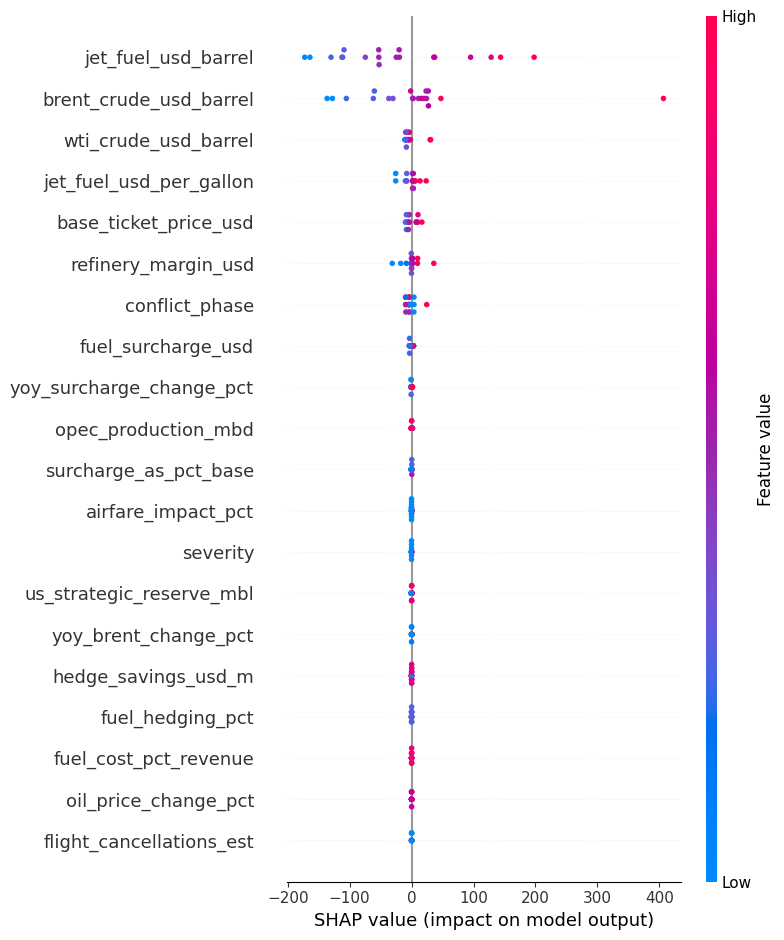

In [243]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist())

06:14:40 - cmdstanpy - INFO - Chain [1] start processing
06:14:46 - cmdstanpy - INFO - Chain [1] done processing


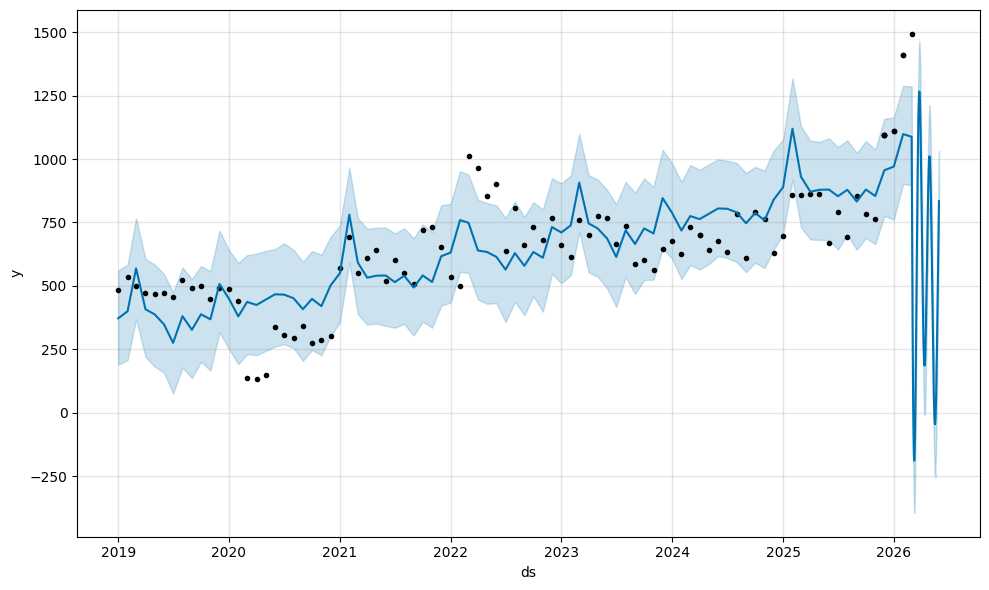

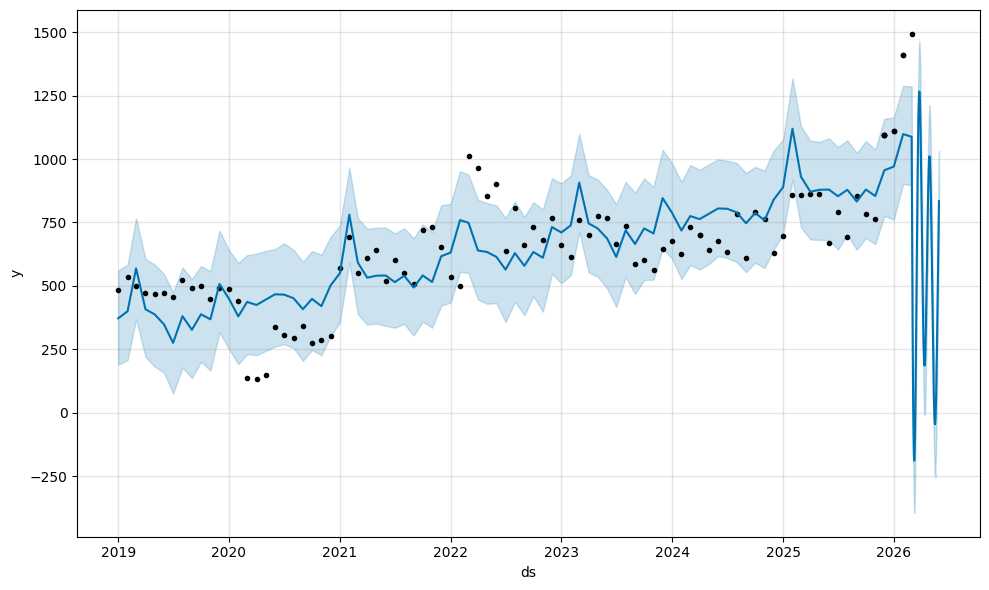

In [244]:
from prophet import Prophet
import pandas as pd

# Préparer les données pour Prophet
df_prophet = df_merged[['month', 'total_ticket_price_usd']].copy()
df_prophet.columns = ['ds', 'y']

# Entraîner Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(df_prophet)

# Prédire 90 jours
future = prophet_model.make_future_dataframe(periods=90, freq='D')
forecast = prophet_model.predict(future)

# Visualiser
prophet_model.plot(forecast)

In [245]:
import pickle

with open("prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

print("✅ Prophet sauvegardé !")

✅ Prophet sauvegardé !


In [246]:
import yfinance as yf

brent = yf.Ticker("BZ=F").history(period="1d")['Close'].iloc[-1]
wti   = yf.Ticker("CL=F").history(period="1d")['Close'].iloc[-1]

print("Brent:", round(brent, 2))
print("WTI:  ", round(wti, 2))

Brent: 100.21
WTI:   96.6


In [247]:
df_merged['price_increase_pct'] = (
    (df_merged['total_ticket_price_usd'] - df_merged['base_ticket_price_usd']) 
    / df_merged['base_ticket_price_usd'] * 100
)

print(df_merged['price_increase_pct'].describe())

count    93.000000
mean     27.423375
std       8.147771
min       6.768760
25%      22.305733
50%      27.751440
75%      31.637227
max      45.000085
Name: price_increase_pct, dtype: float64


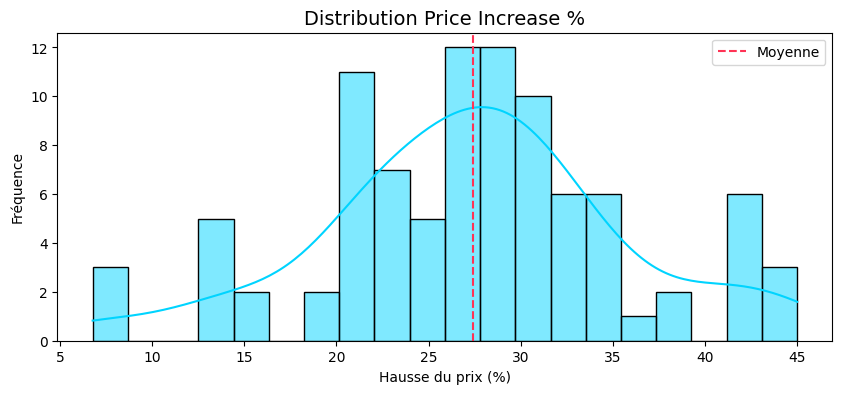

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(df_merged['price_increase_pct'], 
             bins=20, color='#00d4ff', kde=True)
plt.title("Distribution Price Increase %", fontsize=14)
plt.xlabel("Hausse du prix (%)")
plt.ylabel("Fréquence")
plt.axvline(df_merged['price_increase_pct'].mean(), 
            color='#ff3355', linestyle='--', label='Moyenne')
plt.legend()
plt.show()

In [257]:
# Variable cible = prix de base
y_base = df_merged['base_ticket_price_usd']

X_base = df_merged[['actual_distance_km',
                     'fuel_hedging_pct',
                     'fuel_cost_pct_revenue',
                     'profit_margin_pct',
                     'hedge_savings_usd_m',
                     'refinery_margin_usd',
                     'jet_fuel_usd_barrel']]

print(X_base.shape)

print(y_base.describe())

(93, 7)
count      93.000000
mean      516.391269
std       164.600159
min       126.245833
25%       416.040278
50%       517.612778
75%       590.088056
max      1029.575833
Name: base_ticket_price_usd, dtype: float64


In [258]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

# Scaling
scaler_base = StandardScaler()
X_train_b_scaled = scaler_base.fit_transform(X_train_b)
X_test_b_scaled = scaler_base.transform(X_test_b)

# Modèle
xgb_base = XGBRegressor(random_state=42)
xgb_base.fit(X_train_b_scaled, y_train_b)
y_pred_base = xgb_base.predict(X_test_b_scaled)

print("R2:", r2_score(y_test_b, y_pred_base))
print("MAE:", mean_absolute_error(y_test_b, y_pred_base))

R2: 0.9639330474678508
MAE: 13.550127195837906


In [259]:
y_increase = df_merged['price_increase_pct']

X_increase = df_merged[['conflict_phase',
                         'severity',
                         'sentiment_score',
                         'oil_price_change_pct',
                         'flight_cancellations_est',
                         'airspace_closures_countries',
                         'strait_hormuz_disrupted',
                         'brent_crude_usd_barrel',
                         'yoy_brent_change_pct',
                         'fuel_surcharge_usd',
                         'surcharge_as_pct_base',
                         'rerouted',
                         'extra_fuel_cost_usd']]

print(X_increase.shape)

(93, 13)


In [260]:
# Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_increase, y_increase, test_size=0.2, random_state=42
)

# Scaling
scaler_increase = StandardScaler()
X_train_i_scaled = scaler_increase.fit_transform(X_train_i)
X_test_i_scaled = scaler_increase.transform(X_test_i)

# Modèle
xgb_increase = XGBRegressor(random_state=42)
xgb_increase.fit(X_train_i_scaled, y_train_i)
y_pred_increase = xgb_increase.predict(X_test_i_scaled)

print("R2:", r2_score(y_test_i, y_pred_increase))
print("MAE:", mean_absolute_error(y_test_i, y_pred_increase))

R2: 0.9467597332344342
MAE: 1.0704408080551362


In [261]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train_i_scaled, y_train_i)
    y_pred = model.predict(X_test_i_scaled)
    return r2_score(y_test_i, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Meilleur R2:", study.best_value)
print("Meilleurs paramètres:", study.best_params)

[I 2026-05-25 06:35:25,262] A new study created in memory with name: no-name-851875f3-ee7f-4738-b2df-d9c6faf2c832
[I 2026-05-25 06:35:26,231] Trial 0 finished with value: 0.9619970788782791 and parameters: {'n_estimators': 419, 'max_depth': 5, 'learning_rate': 0.29857633274435136, 'subsample': 0.601538063218331, 'colsample_bytree': 0.8241928564814691}. Best is trial 0 with value: 0.9619970788782791.
[I 2026-05-25 06:35:26,894] Trial 1 finished with value: 0.9689722091127096 and parameters: {'n_estimators': 363, 'max_depth': 5, 'learning_rate': 0.18943068050291548, 'subsample': 0.7870886361264445, 'colsample_bytree': 0.9765638908197993}. Best is trial 1 with value: 0.9689722091127096.
[I 2026-05-25 06:35:27,133] Trial 2 finished with value: 0.9625678465870838 and parameters: {'n_estimators': 196, 'max_depth': 4, 'learning_rate': 0.24250224405681176, 'subsample': 0.912295816297821, 'colsample_bytree': 0.9383923816892297}. Best is trial 1 with value: 0.9689722091127096.
[I 2026-05-25 06:3

Meilleur R2: 0.9789216122764792
Meilleurs paramètres: {'n_estimators': 261, 'max_depth': 5, 'learning_rate': 0.19639505353196465, 'subsample': 0.8044411350567542, 'colsample_bytree': 0.6278113030761494}


In [262]:
best_increase_model = XGBRegressor(
    n_estimators=261,
    max_depth=5,
    learning_rate=0.19639505353196465,
    subsample=0.8044411350567542,
    colsample_bytree=0.6278113030761494,
    random_state=42
)

best_increase_model.fit(X_train_i_scaled, y_train_i)
y_pred_final = best_increase_model.predict(X_test_i_scaled)

print("R2 final:", r2_score(y_test_i, y_pred_final))
print("MAE final:", mean_absolute_error(y_test_i, y_pred_final))

R2 final: 0.9789216122764792
MAE final: 0.7926601685987739


In [263]:
def objective_base(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train_b_scaled, y_train_b)
    y_pred = model.predict(X_test_b_scaled)
    return r2_score(y_test_b, y_pred)

study_base = optuna.create_study(direction='maximize')
study_base.optimize(objective_base, n_trials=50)

print("Meilleur R2:", study_base.best_value)
print("Meilleurs paramètres:", study_base.best_params)

[I 2026-05-25 06:38:56,930] A new study created in memory with name: no-name-459c5651-0f60-447a-825a-1737edd5b974
[I 2026-05-25 06:38:58,054] Trial 0 finished with value: 0.966772014133357 and parameters: {'n_estimators': 202, 'max_depth': 4, 'learning_rate': 0.19416104633786446, 'subsample': 0.6028805530163278, 'colsample_bytree': 0.7417851435023475}. Best is trial 0 with value: 0.966772014133357.
[I 2026-05-25 06:38:58,976] Trial 1 finished with value: 0.9579621646749303 and parameters: {'n_estimators': 287, 'max_depth': 3, 'learning_rate': 0.29499296822049825, 'subsample': 0.8853813370612905, 'colsample_bytree': 0.8797501843362066}. Best is trial 0 with value: 0.966772014133357.
[I 2026-05-25 06:38:59,870] Trial 2 finished with value: 0.9476249159321198 and parameters: {'n_estimators': 128, 'max_depth': 6, 'learning_rate': 0.26903689635976813, 'subsample': 0.8500322686066905, 'colsample_bytree': 0.7222932831033826}. Best is trial 0 with value: 0.966772014133357.
[I 2026-05-25 06:39:

Meilleur R2: 0.9869286191091634
Meilleurs paramètres: {'n_estimators': 168, 'max_depth': 5, 'learning_rate': 0.03241801842047883, 'subsample': 0.6577104880712358, 'colsample_bytree': 0.7228373370830785}


In [264]:
best_base_model = XGBRegressor(
    n_estimators=168,
    max_depth=5,
    learning_rate=0.03241801842047883,
    subsample=0.6577104880712358,
    colsample_bytree=0.7228373370830785,
    random_state=42
)

best_base_model.fit(X_train_b_scaled, y_train_b)
y_pred_base_final = best_base_model.predict(X_test_b_scaled)

print("R2 final:", r2_score(y_test_b, y_pred_base_final))
print("MAE final:", mean_absolute_error(y_test_b, y_pred_base_final))

R2 final: 0.9869286191091634
MAE final: 13.052635997749908


In [265]:
import pickle

# Modèle 1 — Prix de base
with open("base_price_model.pkl", "wb") as f:
    pickle.dump(best_base_model, f)

with open("base_price_scaler.pkl", "wb") as f:
    pickle.dump(scaler_base, f)

# Modèle 2 — Hausse conflit
with open("increase_model.pkl", "wb") as f:
    pickle.dump(best_increase_model, f)

with open("increase_scaler.pkl", "wb") as f:
    pickle.dump(scaler_increase, f)

print("✅ 4 fichiers sauvegardés !")

✅ 4 fichiers sauvegardés !
